# Example 2 - Mono + Duo transit fitting example

Let's fit a system which has both a duo transit, and a single/monotransit.

First some imports:

In [2]:
from MonoTools.MonoTools import fit,tools,starpars,lightcurve

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## E2 - Loading and plotting the lightcurve

Here we do not initially see much, although the keen-eyed will spot a couple of planets of the inner planet

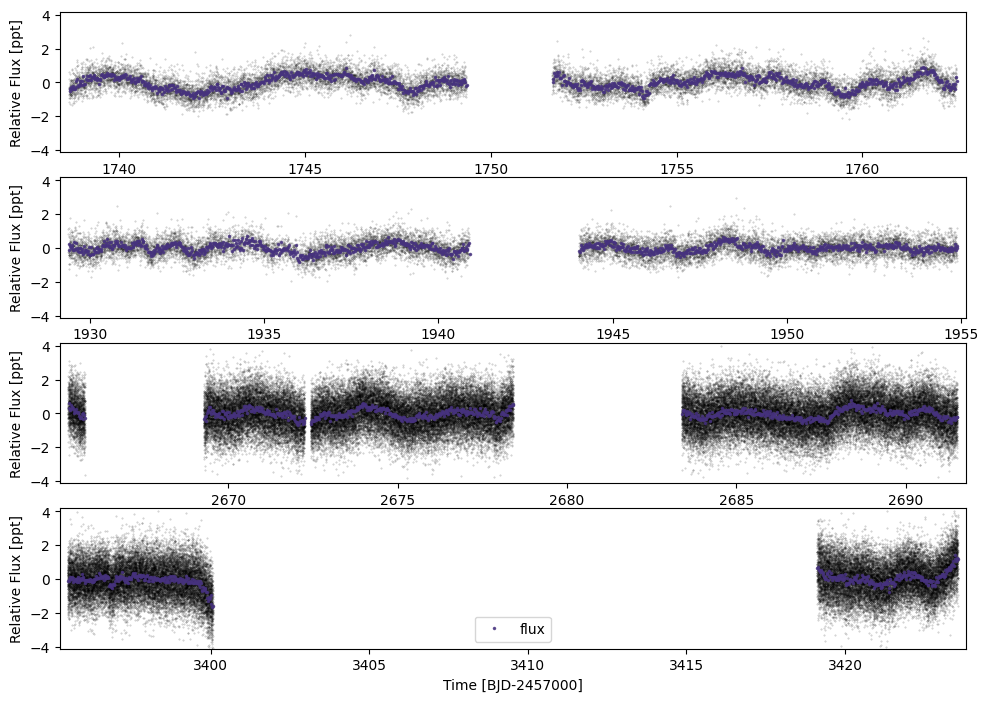

In [3]:
tic=158075010
lc=lightcurve.multilc(tic,'tess',load=True,do_search=False,update_tess_file=False)
lc.plot(savepng=False)

#### E2 - Plotting raw flux

We need to specify to plot the "raw_flux" timeseries (and to specify not to plot with the flux mask using `plot_masked=False`) in order to see the transit of the outer planet.

We also include the ephemeris in the plotting with the `plot_ephem` dict. 

mask_sum 221623 masked: 0


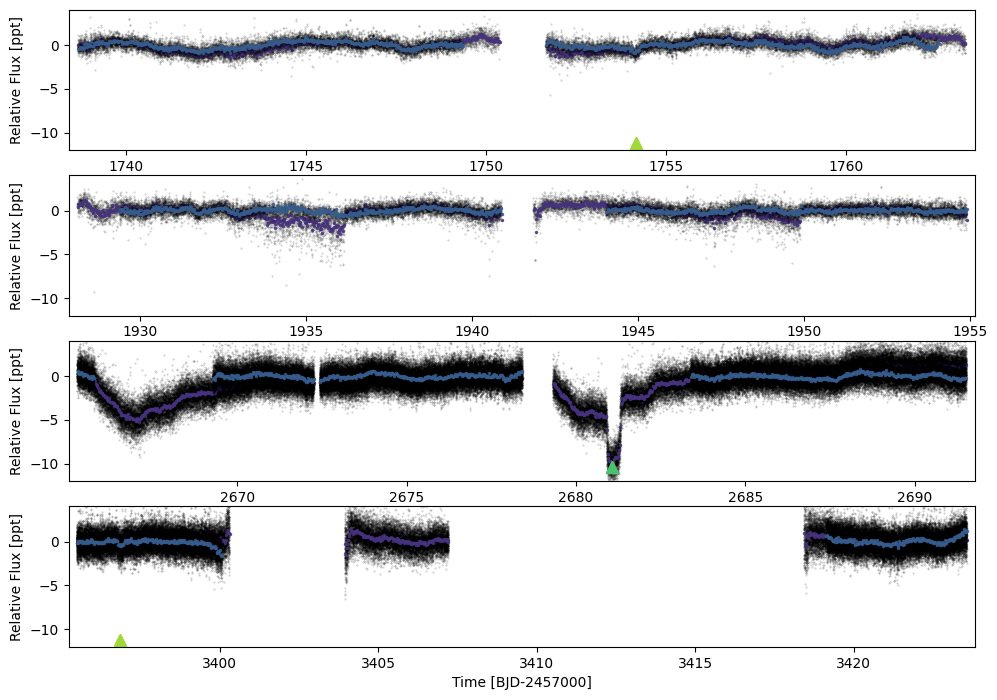

In [4]:
lc.plot(timeseries=['raw_flux','flux'],plot_masked=False,
        plot_ephem={'b':{'p':(3396.87-1754.15),'t0':3396.87,'dur':0.22},
                    'c':{'p':101,'t0':2681.06}},
        savepng=False,ylim=(-12,4),
        plot_legend=False,
        plot_rows=4)

#### E2 - Stitching on the missing flux

In most places, the PDC lightcurve looks better, so let's just use that and add in the SAP "raw" lightcurve where it looks OK.

In [5]:
lc.flux[abs(lc.time-1943)<0.6]=lc.raw_flux[abs(lc.time-1943)<0.6]
lc.flux[abs(lc.time-1928.5)<1.2]=lc.raw_flux[abs(lc.time-1928.5)<1.2]
lc.flux[abs(lc.time-2667.5)<1.6]=lc.raw_flux[abs(lc.time-2667.5)<1.6]
lc.flux[abs(lc.time-2681.2)<2.2]=lc.raw_flux[abs(lc.time-2681.2)<2.2]
lc.flux[abs(lc.time-3406)<0.4]=lc.raw_flux[abs(lc.time-3406)<0.4]
lc.flux[abs(lc.time-3418.9)<0.3]=lc.raw_flux[abs(lc.time-3418.9)<0.3]
lc.mask=np.isfinite(lc.flux)#Making sure no flux_err nans have passed through

#We also need to remove the binned array, otherwise this remains the old version:
lc.remove_binned_arrs()

In [6]:
#We have flux_errs which are masked too. Looping through eacn cadence and restoring them to their medians
for cad in lc.cadence_list:
    lc.flux_err[np.isnan(lc.flux_err)&lc.mask&(lc.cadence==cad)]=1.5*np.nanmedian(lc.flux_err[(~np.isnan(lc.flux_err))&lc.mask&(lc.cadence==cad)])
    

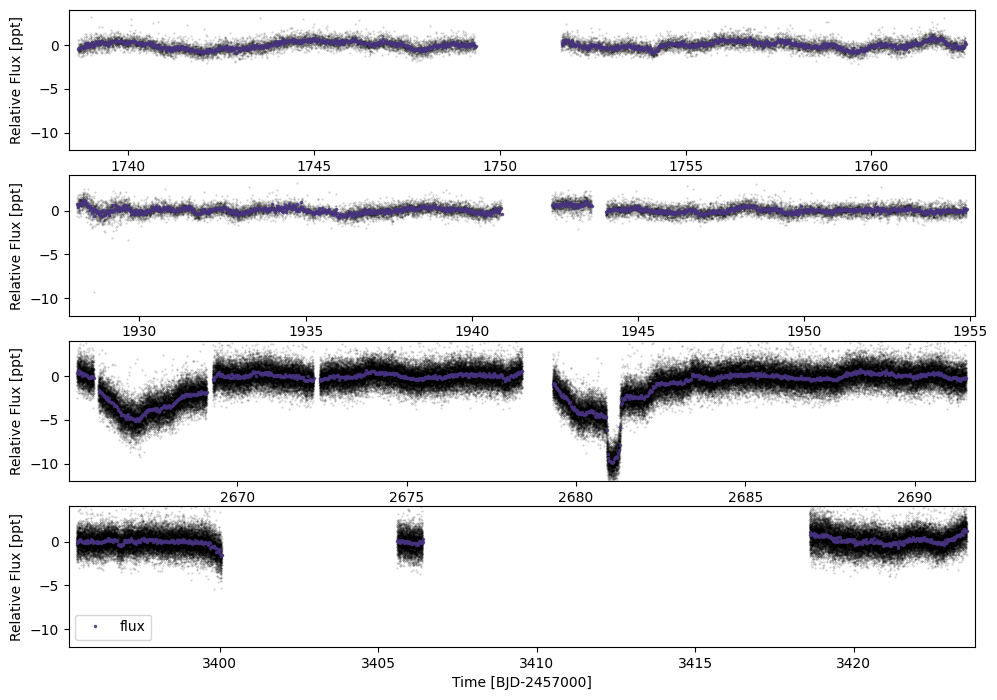

In [7]:
lc.plot(ylim=(-12,4))

Ok, that looks good.

#### E2 -  Plotting the spline-flattened array

We can flatten the lightcurve with `lc.flatten` and then plot using `lc.plot(timeseries=['flux_flat'])`.

By giving `ephems` the flattening masks the transits. `knot_dist=1.25` gives the distance between spline knots (in days).

[1738.6438602  1751.6477999  1928.10289567 2665.2678298  3395.48299942
 3417.14706037] [1750.35337496 1763.31579409 1954.87794144 2691.51400225 3407.20848631
 3423.55322543]
[1738.6438602  1751.6477999  1928.10289567 2665.2678298  3395.48299942
 3417.14706037] [1750.35337496 1763.31579409 1954.87794144 2691.51400225 3407.20848631
 3423.55322543]


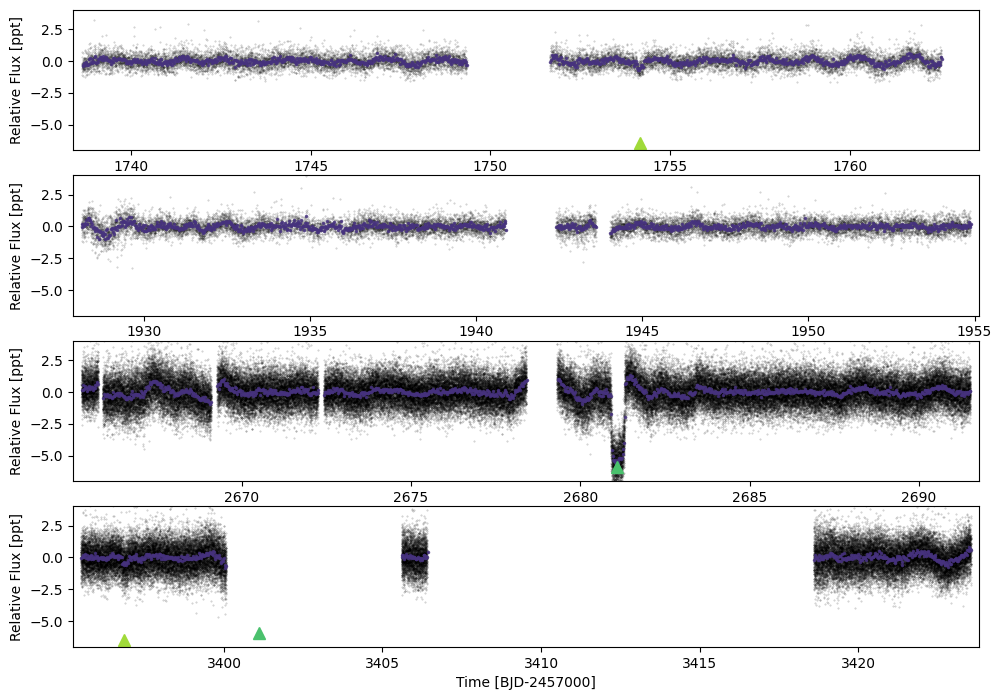

In [9]:
ephs={'b':{'p':(3396.85-1754.15),'t0':3396.85,'dur':0.22}, 'c':{'p':60,'t0':2681.09,'dur':0.3}}
lc.flatten(ephems=ephs,knot_dist=1.25)
lc.plot(timeseries=['flux_flat'],plot_masked=False,
        savepng=False,plot_ephem=ephs,
        plot_legend=False,ylim=(-7,4),plot_rows=4)

Eyeballing the duration of the transit of c:

[1738.6438602  1751.6477999  1928.10289567 2665.2678298  3395.48299942
 3417.14706037] [1750.35337496 1763.31579409 1954.87794144 2691.51400225 3407.20848631
 3423.55322543]


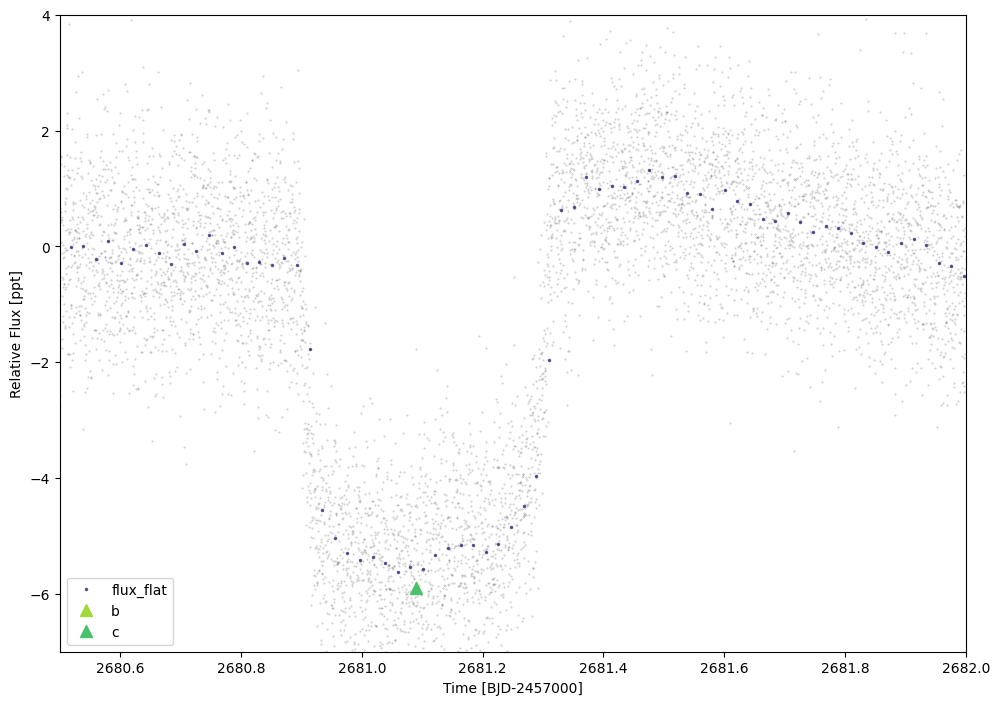

In [10]:
lc.plot(timeseries=['flux_flat'],savepng=False,plot_ephem=ephs,ylim=(-7,4),xlim=(2680.5,2682))

About 0.4d

## E2 - Initialising the duotransit + monotransit model

`fit.monoModel` requires a mission id (e.g. TIC, EPIC, KIC), the associated mission (i.e. `tess` for TIC), and the lightcurve.

To add planets:
- `add_mono` - a single transit. 
- `add_ambiguous` - the general case of N transits but multiple possible compatible periods
- `add_duo` - a special case of the ambiguous case with only two transits
- `add_multi` - for planets with multiple transits (and a solved period)
Each function requires a dictionary of initial values (`tcen` for multi/monos otherwise `tcens`, `tdur` (in hours), `depth` (as a ratio), etc followed by the planet name (i.e. `'b'`)

You can also remove planets using:
- `remove_planet` and specifying the planet name

`init_starpars` then initialises the stellar parameters (using TIC values in this case).

In [11]:
mod=fit.monoModel(tic, 'tess', lc=lc)
#mod.add_planet('multi',{'tcen':ephs['b']['t0'],'period':ephs['b']['p'],'tdur':ephs['b']['dur'],'depth':0.4e-3},'b',update_per=True)
#mod.add_ambiguous({'tcens':[1754.146,2677.94,3396.876],'tdur':0.21,'depth':0.65e-3}, 'b',perthresh=1e-3)
mod.add_duo({'tcens':[1754.146,3396.876],'tdur':0.21,'depth':0.65e-3}, 'b')
mod.add_mono({'tcen':2681.09,'tdur':0.41,'depth':5.5e-3}, 'c')
mod.init_starpars()

1.5214803457025445 [157.06165571 167.47024345 178.56861571]
2.423051440884875 [188.50537571 201.31758206 215.00059982 229.61361571]
2.443562572406266 [250.98445571 268.17853692 286.55052546 306.18111571]
1.5213794883304348 [314.14413571 334.96135407 357.15805571]
2.4424906795133134 [376.48709571 402.26832659 429.81501469 459.24805571]
5.732328539471516 [471.22661571 505.05889928 541.32021247 580.18495042 621.84002912
 666.48578447 714.33693571]
2.4401940013775683 [753.06307571 804.58617287 859.63437919 918.44887571]
3.6244520615392375 [ 942.54211571 1011.47016477 1085.43891797 1164.8170017  1250.        ]


##### The stored initial planet info

Is all in `mod.planets`. There's a bunch of metadata here useful for initialising the modelling.

In [12]:
mod.planets

{'b': {'tcens': array([1754.146, 3396.876]),
  'tdur': 0.21,
  'depth': 0.00065,
  'span': 1642.7300000000002,
  'period_int_aliases': array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8., 10., 11., 12., 13., 14.,
         15., 19., 20., 21., 22., 24., 26., 29., 31., 35., 38., 40., 49.]),
  'period_aliases': array([1642.73      ,  821.365     ,  547.57666667,  410.6825    ,
          328.546     ,  273.78833333,  234.67571429,  205.34125   ,
          164.273     ,  149.33909091,  136.89416667,  126.36384615,
          117.33785714,  109.51533333,   86.45947368,   82.1365    ,
           78.2252381 ,   74.66954545,   68.44708333,   63.18192308,
           56.64586207,   52.99129032,   46.93514286,   43.22973684,
           41.06825   ,   33.52510204]),
  'P_min': 33.52510204081633,
  'npers': 26,
  'ror': 0.025495097567963924,
  'b': 0.9438100141785555,
  'b_src': 'median_alias',
  'boolean_tcen_zero_index': array([0, 0, 0, ..., 0, 0, 0]),
  'boolean_tcen_prox_index': array([[ True, False],
 

## E2 - Initialising the lightcurve modelling

There are two main options - with or without a Gaussian Process. 

#### With a GP
Set `use_GP=True`. This means a `celerite` simple harmonic osscilator Gaussian Process will be co-modelled alongside the transit models.

Using `bin_oot=True` and `cut_distance=1.25` means that photometry more than 1.25 transit durations away from the transit centres will be binned (to 30mins).

By default, `train_GP=True`, which means that out-of-transit data is inially fit with a GP. This will help assess the lightcurve GP hyperparameters in order to set relatively constraining priors. These priors can be simple Gaussians, or more complex interpolated functions using `gp_prior_interp=True` (though covariances are ignored).

#### Pre-detrending without a GP
`use_GP=False` will use a bspline-fitting method (masking the identified transits). 

This will be faster, but in cases with relatively high-amplitude noise/stellar activity close in duration to the transit, a GP will be more robust. In this case, we do not need all of the data, so we can cut the out-of-transit data, here to 2.5 transit durations from t0, using `cut_distance=2.5`.

### Additionally
- `bin_all=True` will bin all the data including in-transit points.
- `fit_no_flatten=True` will not perform any flattening and assume the lightcurve is already flat with out-of-transit flux at ~0.0.

In [13]:
mod.init_lc(use_GP=True, cut_distance=1.25, bin_oot=True, train_gp=True)
mod.init_GP()#We don't need to restate default parameters here - they are saved internally (see `mod.defaults`)

[-719.13592002 -719.13568854 -719.13545706 ... -718.73661668 -718.7363852
 -718.73615372] 2646
[3.34992002 3.34968854 3.34945706 ... 2.95061668 2.9503852  2.95015372] 4428
initialising the GP


Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [logs2_ts_120, phot_mean_ts_120, logs2_ts_20, phot_mean_ts_20, w0, sigma]


Sampling 4 chains for 594 tune and 900 draw iterations (2_376 + 3_600 draws total) took 281 seconds.


## E2 - Initialising the duotransit+monotranist model

There are many options for model fitting:
- `constrain_LD=True` will constrain the limb darkening coefficients to the theoretical values (default is `True`)
- `ld_mult=1.5`. This is the multiplication factor for the theoretical LD params (to account for systematic errors)
- `model_jitter=True` will model a log jitter term for each lightcurve (split into cadences; default is `True`)
- `model_phot_mean=True` will model a mean photometric term for each lightcurve (split into cadences; default is `True`)
- `timing_sigma=0.1` allows the adjustment of the priors on the t0s. The default is to assume they are known to ±0.1tdur.
- `floattype=np.float64` can be adjusted to e.g. `np.float32` to attempt to speed up the model.
- `step_initialise=True` will optimize the model in steps, starting with the most sensitive transit parameters. This is preferred.
- `use_L2=False`. If set to `True`, the model will fit for unincluded "second light" (i.e. contamination; default is `False` and honestly I've never used it).
- `model_ambig_ttv=False`. Useful for trio+ cases. Setting to `True` means the model does not assume a linear ephemeris for these multiple transits, but includes TTVs.

In [14]:
mod.init_model(constrain_LD=True, ld_mult=1.5, floattype=np.float32,
               model_jitter=True, model_phot_mean=True,
               timing_sigma=0.1)

[-719.13592002 -719.13568854 -719.13545706 ... -718.73661668 -718.7363852
 -718.73615372] 2646
[3.34992002 3.34968854 3.34945706 ... 2.95061668 2.9503852  2.95015372] 4428
Initialising ~FAST~ MonoTools model.
initialised planet info
Shape.0
Initialised everything. Optimizing


### E2 -  Plotting the initial duo+mono model:

The models are interpolated to the full input lightcurve and stored in `mod.trans_to_plot` and `mod.gp_to_plot`.

(Additionally, `interactive=True` may produce an interactive Bokeh plot in the browser)

initialising transit
Initalising Transit models for plotting with n_samp= 10
ts_120 successfully interpolated GP means
ts_20 successfully interpolated GP means
0.08910731782477133
0.11527376619871954


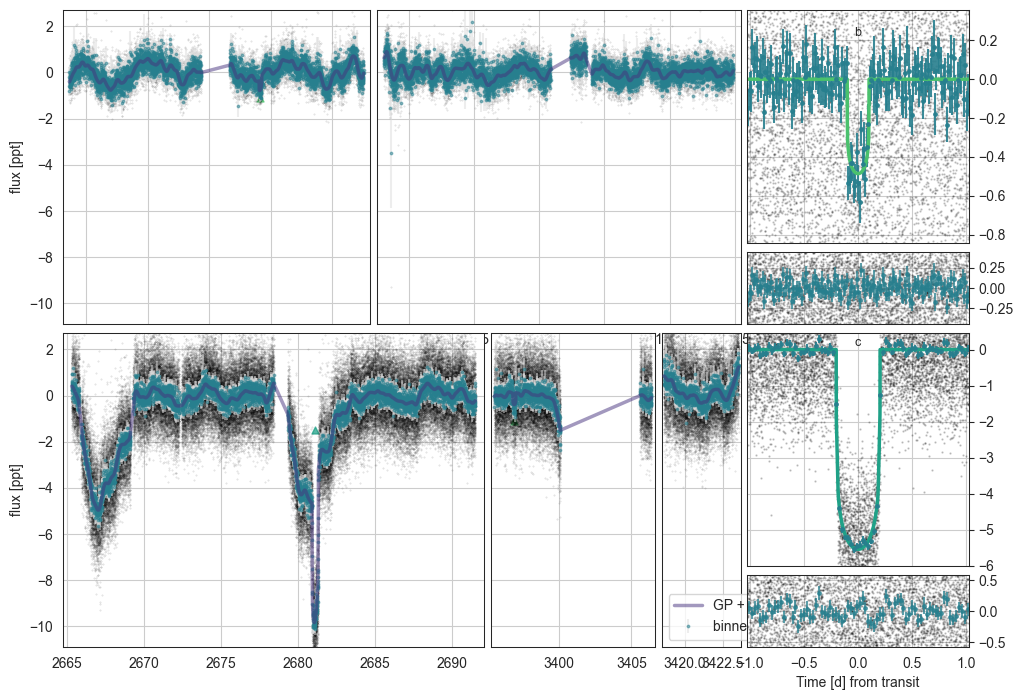

In [15]:
mod.plot(overwrite=True)

## E2 - Sampling the duo+monotransit model

The sampling can be modified in the following ways:
- `n_draws=800` is the number of (post-burn-in) samples per chain
- `n_burnin=1500` is the number of burn-in steps (default is 2/3 of the number of samples but may benefit from being higher if chains are not well distributed)
- `n_chains=6` is the number of chains
- `cores=6` is the number of CPU cores to run on. If cores<n_chains they are run suquentially.
- `sample_method=pm.NUTS` is the default, but other pymc step samplers are possible (note - for Metropolis sampling, `n_draws` needs to be massively scaled up by >10x)

In [16]:
mod.sample_model(n_burnin=1500, n_draws=800, n_chains=6, cores=6)
#Do more draws than this IRL. This is just a demo. GPs are slow (especially with any 20sec cadence data!).

Multiprocess sampling (6 chains in 6 jobs)
NUTS: [Rs, rhostar, t0_b, logror_b, b_b, tdur_b, t0_c, logror_c, b_c, tdur_c, q_star_tess, log_jitter_ts_120, phot_mean_ts_120, log_jitter_ts_20, phot_mean_ts_20, phot_w0, phot_sigma]


Sampling 6 chains for 528 tune and 800 draw iterations (3_168 + 4_800 draws total) took 8212 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 4 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 5 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher n

Saving sampled model parameters to file with shape:  (10927, 14)


## E2 - Plotting the duo+monotransit model

initialising transit
Initalising Transit models for plotting with n_samp= 990
0.10034906678674743
0.13692731729161417


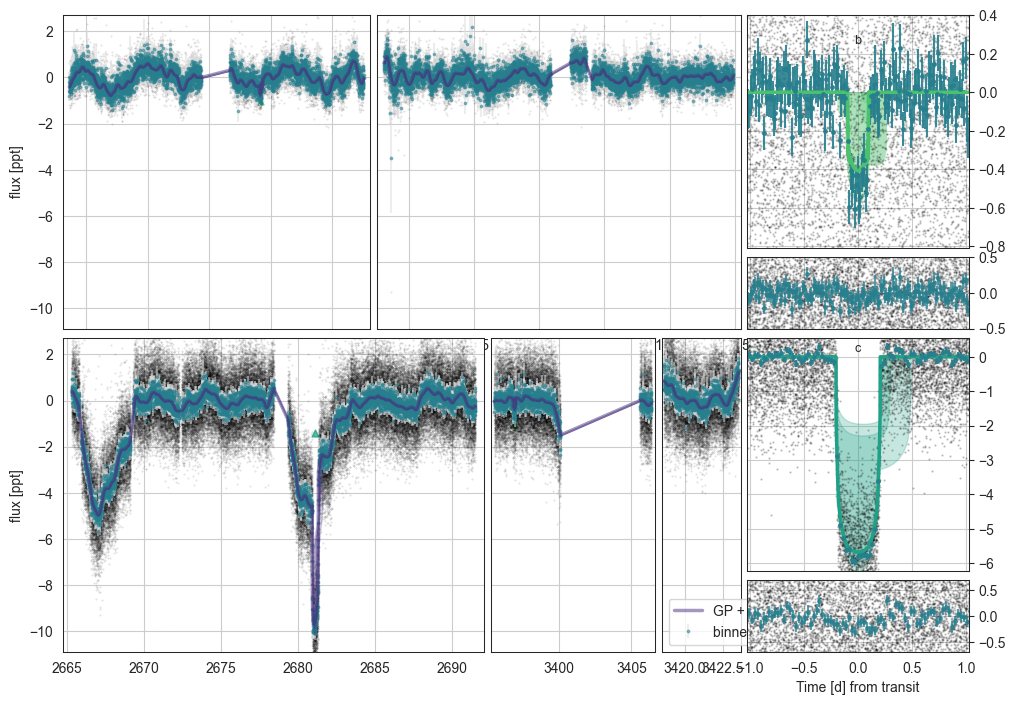

In [19]:
mod.plot()

initialising transit
Initalising Transit models for plotting with n_samp= 990
0.10034906678674743
0.13692731729161417


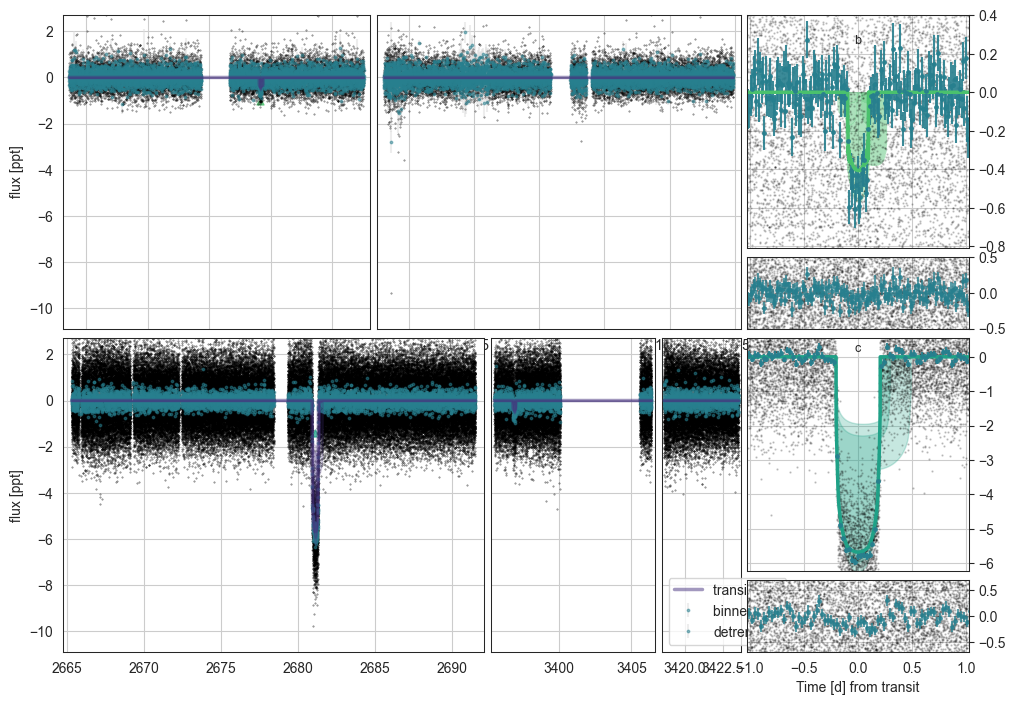

In [20]:
mod.plot(plot_flat=True,overwrite=True)

## E2 - Computing the period probabilities _a posteriori_

In this new version, we fit the transits in a way ambivalent to the periods, and instead only assess the period probabilities using the trace (and various priors). To do this, you have to call `mod.assess_period_from_posterior()`

#### E2 - Eccentricity priors (again)
At this point, key choices have to be made about the eccentricity prior by updating `ecc_prior='auto'`. This is extremely important, as *the uncertainty in your derived period distribution depends highly on the eccentricity prior*, so choose an option that you believe best matches your planet/planetary system. There are the following options:
- `ecc_prior='uniform'` - Planets don't have this distribution in reality. Don't use this. 
- `ecc_prior='kipping'` - The (close-in) Kipping 2013 prior. Derived from RV planets, and therefore dominated by high-mass planets. Potentially OK in those cases.
- `ecc_prior='vaneylen'` - Specifically the multi-planet version derived in VanEylen 2018. Measured for compact multi systems in Kepler. The most e=0-biased prior available (therefore, potentially, the best period logprob constraints)
- `ecc_prior='bernmodel_sing'` - Derived from single planets as produced by Bern model full-system simulations. No observational biases. The Bern Model priors are also all radius-dependent using the initial radius to choose one distribution from [terrestrials, Neptunians or Giants]. The giant case matches `kipping` well, while the smaller planets are much more low-eccentricity.
- `ecc_prior='bernmodel_mult'` - Derived from multi systems produced by Bern model. Radius-dependent (rocky, Neptunian & Giants). These, especially for small planets, are well-constrained to e~0 (though less so than `vaneylen`).
- `ecc_prior='bernmodel_both'` - Derived from all (observable) planets as produced by Bern model full-system simulations.
- `ecc_prior='auto'` - The default is the (radius-constrained) `bernmodel_both` prior for single cases (as we do not know if there could be additional planets), and the `bernmodel_mult` in multi cases.

In [29]:
mod.assess_period_from_posterior()

multis__bernmodel auto {'kipping': 'kip', 'vaneylen': 'vve', 'flat': 'flat', 'apogee': 'apo', 'bernmodel_both': 'both__bernmodel', 'bernmodel_sing': 'singles__bernmodel', 'bernmodel_mult': 'multis__bernmodel', 'auto': 'multis__bernmodel'} mult ['bern', 'auto']
(1, 1, 92) (6, 800, 1) (1, 1, 92) (1, 1, 92)
(6, 800, 92)


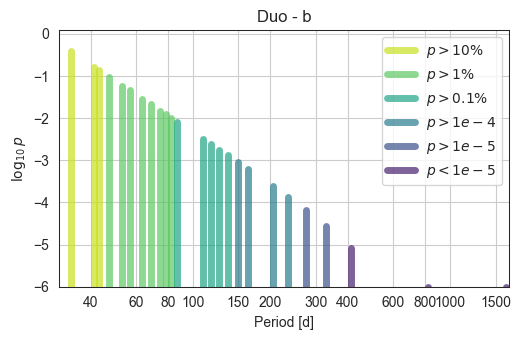

In [41]:
mod.plot_periods(pls=['b'])

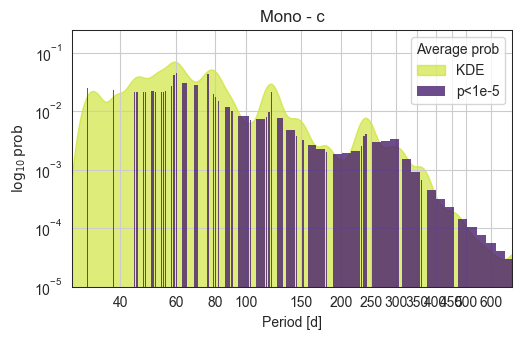

In [216]:
mod.plot_periods(pls=['c'], pmin=28, pmax=700, ymin=1e-5)

The bar chart shows the "true" underlying period distribution which is filled with discontinuities ("period islands") due to photometric data ruling out parts of the period parameter space. The underlying smoothed histogram KDE is the integrated probability per log period bin (plus some normalisation).

## E2 - Other outputs

#### Table
Saved posterior means, SDs, etc.

`mod.make_table()` creates (and saves) the posterior statistics. Check that `ess` is at least a thousand, and `r_hat` is well below 1.05 (ideally below 1.01).

In [217]:
tab=mod.make_table()
tab.to_csv("TOI2074_TIC158075010_best_fit_data.csv")

Saving sampled model parameters to file with shape:  (12121, 14)


In [218]:
tab

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,5%,-$1\sigma$,median,+$1\sigma$,95%
Rs,1.67793,0.14493,1.52552,1.95278,0.05855,0.04358,6.66258,15.09754,3.76868,1.52616,1.52785,1.66153,1.94443,1.95263
rhostar,0.34736,0.08601,0.23237,0.47388,0.03208,0.02368,7.98539,22.81827,2.11955,0.23310,0.25074,0.34329,0.47352,0.47373
t0_b[0],1754.19143,0.06387,1754.13923,1754.29716,0.02593,0.01930,7.03958,22.91852,2.71872,1754.13947,1754.13970,1754.14994,1754.29467,1754.29723
t0_b[1],3396.85587,0.03840,3396.76748,3396.87873,0.01558,0.01159,7.99389,10.51297,2.26618,3396.76862,3396.77349,3396.87123,3396.87578,3396.87858
logror_b,-4.05798,0.36151,-4.96344,-3.79018,0.14446,0.10733,7.19904,11.30369,2.96364,-4.95307,-4.39019,-3.96137,-3.83478,-3.81412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ecc_marg_av_b,0.61206,0.07380,0.47800,0.74699,0.02768,0.02085,6.98548,11.88043,2.85159,0.47799,0.54743,0.61334,0.68563,0.73870
ecc_marg_sd_b,0.00346,0.00104,0.00164,0.00540,0.00039,0.00029,6.95087,11.92449,2.89904,0.00175,0.00241,0.00338,0.00438,0.00541
vel_marg_b,1.76400,0.18457,1.47203,2.17359,0.07135,0.05328,6.98261,11.88043,2.85536,1.47369,1.59873,1.74425,1.94663,2.14058
per_marg_av_b,44.39923,0.20762,44.01327,44.71767,0.07332,0.05394,7.23394,12.13221,2.58105,44.00900,44.24626,44.39091,44.58599,44.69711


#### Future transits

In [219]:
trans=mod.predict_future_transits(time_dur=500)
trans.to_csv("TOI2074_TIC158075010_future_trans.csv")
trans

time range 2025-06-06T15:29:59.974 -> 2026-10-19T15:29:59.978


,transit_mid_date,transit_mid_med,transit_dur_med,transit_dur_-1sig,transit_dur_+1sig,transit_start_+2sig,transit_start_+1sig,transit_start_med,transit_start_-1sig,transit_start_-2sig,...,planet_name,alias_n,alias_p,aliases_ns,aliases_ps,total_prob,num_aliases,in_TESS,sun_separation,moon_separation
0,2025-06-08T10:20:19.417,3834.930780,0.189964,0.174189,0.219486,3834.854084,3834.848338,3834.835798,3834.666661,3834.653777,...,duo_b,13,109.514850,13,109.5148,0.003209,1.0,False,104.717485,64.074628
1,2025-06-12T15:25:45.560,3839.142888,0.189964,0.174189,0.219486,3839.066211,3839.060457,3839.047906,3838.878227,3838.865317,...,duo_b,19,63.181644,19,63.1816,0.029391,1.0,False,102.506298,90.046849
2,2025-06-18T09:16:48.991,3844.886678,0.189964,0.174189,0.219486,3844.810021,3844.804251,3844.791696,3844.621272,3844.608326,...,duo_b,9,149.338431,"9,17","149.3384,74.6692",0.015923,2.0,False,99.425237,122.850513
3,2025-06-22T02:52:59.786,3848.620136,0.189964,0.174189,0.219486,3848.543498,3848.537719,3848.525154,3848.354252,3848.341282,...,duo_b,24,41.068069,24,41.0681,0.167789,1.0,False,97.390300,116.062177
4,2025-06-23T12:52:14.225,3850.036276,0.189964,0.174189,0.219486,3849.959644,3849.953862,3849.941294,3849.770209,3849.757231,...,duo_b,20,56.645612,20,56.6456,0.045633,1.0,False,96.613200,106.635811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,2026-09-14T05:16:03.836,4297.719489,0.189964,0.174189,0.219486,4297.644357,4297.637804,4297.624507,4297.395514,4297.379884,...,duo_b,21,52.991056,21,52.9911,0.059724,1.0,False,57.323754,60.229298
82,2026-09-16T20:51:25.255,4300.369042,0.189964,0.174189,0.219486,4300.293922,4300.287359,4300.274060,4300.044725,4300.029079,...,duo_b,15,82.136137,"15,24","82.1361,41.0681",0.178020,2.0,False,56.680081,71.828838
83,2026-09-18T13:05:13.091,4302.045290,0.189964,0.174189,0.219486,4301.970179,4301.963609,4301.950308,4301.720756,4301.705101,...,duo_b,25,33.524954,25,33.525,0.385548,1.0,False,56.309626,81.658110
84,2026-09-19T16:49:54.358,4303.201324,0.189964,0.174189,0.219486,4303.126218,4303.119643,4303.106342,4302.876640,4302.860978,...,duo_b,20,56.645612,20,56.6456,0.045633,1.0,False,56.071210,88.883319


#### Cheops ORs

This may take some time as it accesses Gaia data for precise proper motion, Gmag, etc.

Only the most likely aliases will typically be returned, but updating `observe_sigma` to e.g. `10` will vastly increase the number.

In [224]:
ors=mod.make_cheops_OR(pl='b')
ors.to_csv("TOI2074_TIC158075010_cheops_obstable.csv")
ors

time range 2025-06-06T13:38:48.917 -> 2025-07-27T03:20:47.849
SNR for whole transit is:  29.139390214984864
SNR for single orbit in/egress is:  12.332793576608116
17
18
19
20
21
22
23
24
25
Run the following command in a terminal to generate ORs:
"make_xml_files /Users/hugh/Postdoc/Cheops/Duotransits/TIC00158075010/TIC00158075010_2025-06-06_0_output_ORs.csv --auto-expose -f"


,ObsReqName,Target,_RAJ2000,_DEJ2000,pmra,pmdec,parallax,SpTy,Gmag,dr2_g_mag,...,N_Visits,Priority,MinEffDur,Gaia_DR2,BJD_0,Period,Ph_late,Ph_early,Old_T_eff,N_Ranges
0,TIC158075010_b_period74;67_prob0.01,TIC158075010,14:32:44.31912576,43:45:22.83233281,-44.888108,19.90435,7.588751,F5,8.704963,8.704963,...,1,2,45,1493352470894653568,2460396.871231,74.669216,0.997214,0.995928,-99.0,0
1,TIC158075010_b_period68;45_prob0.02,TIC158075010,14:32:44.31912576,43:45:22.83233281,-44.888108,19.90435,7.588751,F5,8.704963,8.704963,...,1,2,45,1493352470894653568,2460396.871231,68.446781,0.996927,0.995524,-99.0,0
2,TIC158075010_b_period63;18_prob0.02,TIC158075010,14:32:44.31912576,43:45:22.83233281,-44.888108,19.90435,7.588751,F5,8.704963,8.704963,...,1,2,45,1493352470894653568,2460396.871231,63.181644,0.996714,0.995194,-99.0,0
3,TIC158075010_b_period56;65_prob0.04,TIC158075010,14:32:44.31912576,43:45:22.83233281,-44.888108,19.90435,7.588751,F5,8.704963,8.704963,...,1,2,45,1493352470894653568,2460396.871231,56.645612,0.996321,0.994625,-99.0,0
4,TIC158075010_b_period52;99_prob0.05,TIC158075010,14:32:44.31912576,43:45:22.83233281,-44.888108,19.90435,7.588751,F5,8.704963,8.704963,...,1,2,45,1493352470894653568,2460396.871231,52.991056,0.996034,0.994222,-99.0,0
5,TIC158075010_b_period46;93_prob0.09,TIC158075010,14:32:44.31912576,43:45:22.83233281,-44.888108,19.90435,7.588751,F5,8.704963,8.704963,...,1,2,45,1493352470894653568,2460396.871231,46.934936,0.995534,0.993488,-99.0,0
6,TIC158075010_b_period43;23_prob0.13,TIC158075010,14:32:44.31912576,43:45:22.83233281,-44.888108,19.90435,7.588751,F5,8.704963,8.704963,...,1,1,45,1493352470894653568,2460396.871231,43.229546,0.995141,0.992919,-99.0,0
7,TIC158075010_b_period41;07_prob0.16,TIC158075010,14:32:44.31912576,43:45:22.83233281,-44.888108,19.90435,7.588751,F5,8.704963,8.704963,...,1,1,45,1493352470894653568,2460396.871231,41.068069,0.994928,0.992589,-99.0,0
8,TIC158075010_b_period33;52_prob0.38,TIC158075010,14:32:44.31912576,43:45:22.83233281,-44.888108,19.90435,7.588751,F5,8.704963,8.704963,...,1,1,45,1493352470894653568,2460396.871231,33.524954,0.993748,0.990883,-99.0,0


### E2 - Saving to file

Outputs are typically stored in the `MonoTools/data/TIC00XXXXXXXXX` folder, including the pickled dictionary of model parameters, the `_trace.nc` arviz posterior object, and all plots.

The model can then be reloaded by running `mod.load_model_from_file(loadfile=savefileloc)`

In [222]:
mod.save_model_to_file()

In [1]:
#some loading just for me

import os
#The followg may need to be MonoTools.MonoTools if you are outside the MonoTools folder when importing:
os.environ['MONOTOOLSPATH']='/Users/hugh/Postdoc/Cheops/Duotransits'
%load_ext autoreload
%autoreload 2
import pytensor
pytensor.config.gcc__cxxflags = '-fbracket-depth=512'

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
